# Core Probability Distributions Visualization

This notebook is the visual companion to `rsc/core_probability_distributions_handout.md`.

It focuses on the core families emphasized in that handout:
- Bernoulli
- Poisson
- Uniform
- Normal
- Exponential

To strengthen visual intuition, it also includes the **Binomial distribution** as a natural extension of Bernoulli: instead of one yes/no trial, we count successes across many Bernoulli trials.

The central teaching idea is simple:

A probability distribution is not just a formula. It is a **family of possible shapes**, and the parameters control where the mass sits, how spread out it is, how skewed it is, and how heavy the tails are.

## Section 1 - Why these plots matter

In sequential decision analytics and modelling, probability distributions are the building blocks of uncertainty models. We use them to represent uncertain demand, arrivals, waiting times, failures, noise, and many other random quantities.

This notebook is designed to build visual intuition for three ideas:

1. **A distribution family is not one fixed curve.** Changing parameters changes the shape.
2. **Random samples make the abstract formulas concrete.** Histograms and empirical frequencies show what repeated randomness looks like.
3. **Theoretical PMFs/PDFs explain the long-run pattern.** With enough samples, the empirical picture starts to resemble the underlying distribution.

We will compare several members of the same family on one plot so it becomes visually obvious what the parameters are doing.

We will also keep the difference between **discrete** and **continuous** distributions visible:
- discrete distributions place probability mass on countable values such as `0, 1, 2, ...`
- continuous distributions spread probability density over intervals of real values

## Section 2 - Common plotting setup

We use one fixed random seed for reproducibility and a fairly large sample size per parameter setting.

Why large samples?
Because the goal here is didactic. We want the sample histograms and empirical frequencies to resemble the underlying family clearly enough that students can see the structure.

Throughout the notebook:
- `sample_size` controls how many random draws we generate for each parameter setting
- `rng` is the random number generator with a fixed seed
- helper functions keep the plots consistent across families

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, poisson, uniform, norm, expon

seed = 20260419
rng = np.random.default_rng(seed)
sample_size = 8000

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def empirical_pmf(samples, support):
    samples = np.asarray(samples)
    support = np.asarray(support)
    probs = np.array([(samples == x).mean() for x in support], dtype=float)
    return probs



def safe_support_from_samples_and_quantile(samples, lower, upper):
    lo = int(min(np.min(samples), lower))
    hi = int(max(np.max(samples), upper))
    return np.arange(lo, hi + 1)



def print_moment_check(name, samples, theory_mean=None, theory_var=None):
    sample_mean = float(np.mean(samples))
    sample_var = float(np.var(samples))
    print(f"{name}")
    print(f"  sample mean     = {sample_mean:.4f}")
    print(f"  sample variance = {sample_var:.4f}")
    if theory_mean is not None:
        print(f"  theory mean     = {theory_mean:.4f}")
    if theory_var is not None:
        print(f"  theory variance = {theory_var:.4f}")
    print()



def l1_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return float(np.sum(np.abs(p - q)))



def plot_discrete_family(title, support, series, xlabel):
    fig, ax = plt.subplots()
    width = 0.8 / max(1, len(series))
    offsets = np.linspace(-0.4 + width / 2, 0.4 - width / 2, len(series))

    for offset, item in zip(offsets, series):
        sample_pmf = empirical_pmf(item["samples"], support)
        ax.bar(support + offset, sample_pmf, width=width, alpha=0.45, label=f'empirical {item["label"]}')
        #ax.plot(support, item["theory"], marker='o', linestyle='-', label=f'theory {item["label"]}')
        ax.plot(support, item["theory"], marker=None, linestyle='-', label=f'theory {item["label"]}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Probability / relative frequency")
    ax.set_xticks(support)
    ax.legend()
    plt.show()



def plot_continuous_family(title, x_grid, series, xlabel, bins=60):
    fig, ax = plt.subplots()
    for item in series:
        ax.hist(item["samples"], bins=bins, density=True, alpha=0.35, label=f'empirical {item["label"]}')
        ax.plot(x_grid, item["theory"], linewidth=2, label=f'theory {item["label"]}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()


print(f"Random seed: {seed}")
print(f"Sample size per parameter setting: {sample_size}")

Random seed: 20260419
Sample size per parameter setting: 8000


## Section 3 - Bernoulli distribution

The **Bernoulli distribution** models a single binary uncertain event.

Examples:
- stockout vs no stockout
- success vs failure
- customer buys vs does not buy
- machine fails vs does not fail

If

$$X \sim \text{Bernoulli}(p),$$

then
- `X = 1` means success
- `X = 0` means failure
- `p` is the probability of success

So the whole shape is controlled by **one parameter**: `p`.

Here we compare several values of `p` and look at how the probability mass shifts between `0` and `1`.

In [ ]:
bernoulli_ps = [0.1, 0.3, 0.5, 0.7, 0.9]
support = np.array([0, 1])
series = []

for p in bernoulli_ps:
    samples = rng.binomial(n=1, p=p, size=sample_size)
    theory = bernoulli.pmf(support, p)
    series.append({
        "label": f"p={p}",
        "samples": samples,
        "theory": theory,
    })

plot_discrete_family(
    title="Bernoulli distribution: how p shifts mass between 0 and 1",
    support=support,
    series=series,
    xlabel="Outcome"
)

p_example = 0.3
example_samples = rng.binomial(n=1, p=p_example, size=sample_size)
print_moment_check(
    name=f"Bernoulli example with p={p_example}",
    samples=example_samples,
    theory_mean=p_example,
    theory_var=p_example * (1 - p_example),
)

### Bernoulli interpretation

This is the simplest possible distribution family.

As `p` increases:
- probability mass moves from `0` to `1`
- the mean increases from near `0` to near `1`
- the variance is largest around `p = 0.5`

This is a good first reminder that **distribution parameters are shape controls**.

## Section 4 - Binomial distribution

The **Binomial distribution** counts how many successes occur across a fixed number of Bernoulli trials.

If

$$X \sim \text{Binomial}(n, p),$$

then:
- `n` is the number of trials
- `p` is the probability of success in each trial
- `X` counts how many successes occur

This is a natural next step after Bernoulli:
- Bernoulli = one trial
- Binomial = many Bernoulli trials added together

We first fix `n = 20` and vary `p`.
Then we hold `p = 0.3` fixed and vary `n` to show how the support and spread change.

In [ ]:
# Comparison 1: fixed n, varying p
n_fixed = 20
binomial_ps = [0.1, 0.3, 0.5, 0.7]
support = np.arange(0, n_fixed + 1)
series = []

for p in binomial_ps:
    samples = rng.binomial(n=n_fixed, p=p, size=sample_size)
    theory = binom.pmf(support, n_fixed, p)
    series.append({
        "label": f"n={n_fixed}, p={p}",
        "samples": samples,
        "theory": theory,
    })

plot_discrete_family(
    title="Binomial distribution: fixed n=20, varying p",
    support=support,
    series=series,
    xlabel="Number of successes"
)

# Comparison 2: fixed p, varying n
p_fixed = 0.3
binomial_ns = [5, 20, 50]
fig, ax = plt.subplots()

for n in binomial_ns:
    samples = rng.binomial(n=n, p=p_fixed, size=sample_size)
    upper = int(max(np.max(samples), binom.ppf(0.999, n, p_fixed)))
    support = np.arange(0, upper + 1)
    pmf_emp = empirical_pmf(samples, support)
    pmf_theory = binom.pmf(support, n, p_fixed)
    ax.plot(support, pmf_emp, marker='o', linestyle='--', alpha=0.8, label=f'empirical n={n}, p={p_fixed}')
    ax.plot(support, pmf_theory, linestyle='-', linewidth=2, label=f'theory n={n}, p={p_fixed}')

ax.set_title("Binomial distribution: fixed p=0.3, varying n")
ax.set_xlabel("Number of successes")
ax.set_ylabel("Probability / relative frequency")
ax.legend()
plt.show()

example_samples = rng.binomial(n=n_fixed, p=p_fixed, size=sample_size)
print_moment_check(
    name=f"Binomial example with n={n_fixed}, p={p_fixed}",
    samples=example_samples,
    theory_mean=n_fixed * p_fixed,
    theory_var=n_fixed * p_fixed * (1 - p_fixed),
)

### Binomial interpretation

When `n` is fixed and `p` changes:
- the center shifts from left to right
- the skewness changes
- the spread depends on both `n` and `p`

When `p` is fixed and `n` changes:
- the support becomes wider
- the distribution becomes smoother
- counts become less "tiny-trial" and more aggregated

This is a good bridge from single-event uncertainty to repeated-trial uncertainty.

## Section 5 - Poisson distribution

The **Poisson distribution** models event counts over a fixed interval when events occur at a constant average rate.

Examples:
- number of arrivals in an hour
- number of customer requests in a day
- number of failures in a month

If

$$X \sim \text{Poisson}(\lambda),$$

then $\lambda$ controls both:
- the mean: $\mathbb{E}[X] = \lambda$
- the variance: $\mathrm{Var}[X] = \lambda$

That is one reason Poisson is mathematically elegant and widely used.

To keep the visualization readable, we split the comparison into:
- small-to-medium rates
- medium-to-large rates

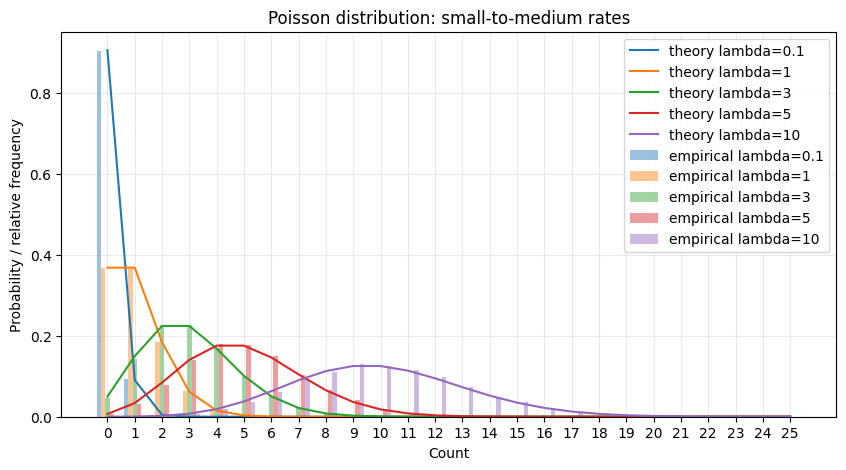

In [8]:
# Small-to-medium rates
poisson_lambdas_small = [0.1, 1, 3, 5, 10]
all_samples_small = []
for lam in poisson_lambdas_small:
    samples = rng.poisson(lam=lam, size=sample_size)
    all_samples_small.append(samples)

upper_small = max(int(poisson.ppf(0.999, lam)) for lam in poisson_lambdas_small)
upper_small = max(upper_small, max(int(np.max(s)) for s in all_samples_small))
support_small = np.arange(0, upper_small + 1)
series_small = []

for lam, samples in zip(poisson_lambdas_small, all_samples_small):
    theory = poisson.pmf(support_small, lam)
    series_small.append({
        "label": f"lambda={lam}",
        "samples": samples,
        "theory": theory,
    })

plot_discrete_family(
    title="Poisson distribution: small-to-medium rates",
    support=support_small,
    series=series_small,
    xlabel="Count"
)



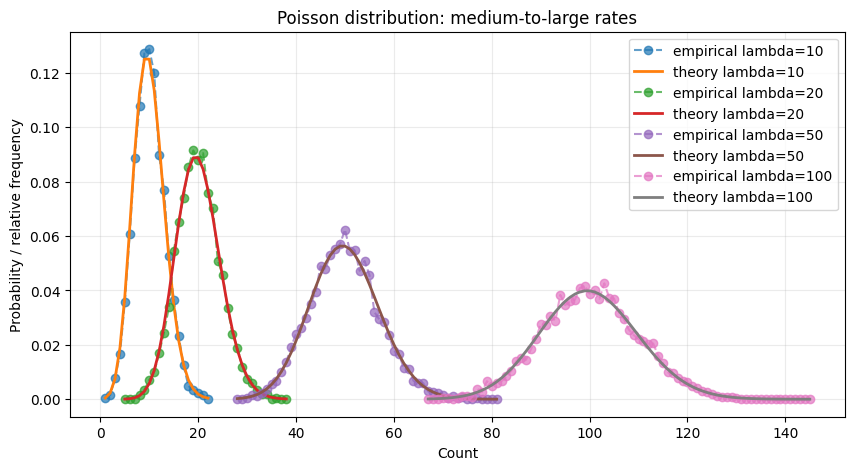

Poisson example with lambda=10
  sample mean     = 9.9977
  sample variance = 9.8747
  theory mean     = 10.0000
  theory variance = 10.0000



In [7]:
# Medium-to-large rates
poisson_lambdas_large = [10, 20, 50, 100]
fig, ax = plt.subplots()

for lam in poisson_lambdas_large:
    samples = rng.poisson(lam=lam, size=sample_size)
    lower = int(max(0, poisson.ppf(0.001, lam)))
    upper = int(poisson.ppf(0.999, lam))
    support = safe_support_from_samples_and_quantile(samples, lower, upper)
    pmf_emp = empirical_pmf(samples, support)
    pmf_theory = poisson.pmf(support, lam)
    ax.plot(support, pmf_emp, marker='o', linestyle='--', alpha=0.7, label=f'empirical lambda={lam}')
    ax.plot(support, pmf_theory, linewidth=2, label=f'theory lambda={lam}')

ax.set_title("Poisson distribution: medium-to-large rates")
ax.set_xlabel("Count")
ax.set_ylabel("Probability / relative frequency")
ax.legend()
plt.show()

lam_example = 10
example_samples = rng.poisson(lam=lam_example, size=sample_size)
print_moment_check(
    name=f"Poisson example with lambda={lam_example}",
    samples=example_samples,
    theory_mean=lam_example,
    theory_var=lam_example,
)

### Formula:

$$\Pr(X = k) = \frac{e^{-\lambda}\lambda^k}{k!}$$

with

- $x$ number of events,
- $k$ a possible event count
- $\lambda$ average number of events in that intervall

### Poisson interpretation

As $\lambda$ increases:
- the center moves to the right
- the distribution spreads out
- the relative skewness decreases
- the shape begins to look more symmetric

For very small $\lambda$, most mass is near zero.
For large $\lambda$, the shape becomes much broader and smoother.

## Section 6 - Uniform distribution

The **Uniform distribution** models a situation where every value in an interval is equally likely.

If

$$X \sim U(a, b),$$

then:
- support is the interval `[a, b]`
- the density is flat on that interval
- the density is zero outside the interval

So the important parameters are the endpoints `a` and `b`.
They control location and width, but not the basic flat shape.

In [ ]:
uniform_intervals = [(0, 1), (0, 5), (-2, 2), (2, 10)]
series = []

x_min = min(a for a, b in uniform_intervals) - 1
x_max = max(b for a, b in uniform_intervals) + 1
x_grid = np.linspace(x_min, x_max, 800)

for a, b in uniform_intervals:
    samples = rng.uniform(low=a, high=b, size=sample_size)
    theory = uniform.pdf(x_grid, loc=a, scale=b - a)
    series.append({
        "label": f"U({a}, {b})",
        "samples": samples,
        "theory": theory,
    })

plot_continuous_family(
    title="Uniform distribution: changing the interval changes the support",
    x_grid=x_grid,
    series=series,
    xlabel="Value",
    bins=50,
)

example_a, example_b = 0, 5
example_samples = rng.uniform(low=example_a, high=example_b, size=sample_size)
print_moment_check(
    name=f"Uniform example with U({example_a}, {example_b})",
    samples=example_samples,
    theory_mean=(example_a + example_b) / 2,
    theory_var=((example_b - example_a) ** 2) / 12,
)

### Uniform interpretation

The Uniform family is useful because it separates two ideas cleanly:
- **support** tells us where values can occur
- **flat density** tells us there is no preferred location inside that support

Changing the interval moves or stretches the distribution, but the defining feature remains the same: equal likelihood within the range.

## Section 7 - Normal distribution

The **Normal distribution** is the classic symmetric bell-shaped family.

If

$$X \sim \mathcal N(\mu, \sigma^2),$$

then:
- $\mu$ controls location
- $\sigma$ controls spread

This is a very important visual separation:
- changing the mean shifts the bell left or right
- changing the standard deviation makes the bell narrower or wider

We use two plots so those effects stay clean.

In [ ]:
# Vary mean, hold sigma fixed
normal_means = [-2, 0, 2]
sigma_fixed = 1
x_grid = np.linspace(-8, 8, 1000)
series = []

for mu in normal_means:
    samples = rng.normal(loc=mu, scale=sigma_fixed, size=sample_size)
    theory = norm.pdf(x_grid, loc=mu, scale=sigma_fixed)
    series.append({
        "label": f"mu={mu}, sigma={sigma_fixed}",
        "samples": samples,
        "theory": theory,
    })

plot_continuous_family(
    title="Normal distribution: varying the mean with fixed spread",
    x_grid=x_grid,
    series=series,
    xlabel="Value",
    bins=60,
)

# Vary sigma, hold mean fixed
mu_fixed = 0
normal_sigmas = [0.5, 1, 2, 4]
series = []

for sigma in normal_sigmas:
    samples = rng.normal(loc=mu_fixed, scale=sigma, size=sample_size)
    theory = norm.pdf(x_grid, loc=mu_fixed, scale=sigma)
    series.append({
        "label": f"mu={mu_fixed}, sigma={sigma}",
        "samples": samples,
        "theory": theory,
    })

plot_continuous_family(
    title="Normal distribution: varying the spread with fixed mean",
    x_grid=x_grid,
    series=series,
    xlabel="Value",
    bins=60,
)

mu_example, sigma_example = 0, 2
example_samples = rng.normal(loc=mu_example, scale=sigma_example, size=sample_size)
print_moment_check(
    name=f"Normal example with mu={mu_example}, sigma={sigma_example}",
    samples=example_samples,
    theory_mean=mu_example,
    theory_var=sigma_example ** 2,
)

### Normal interpretation

The Normal family is especially useful because it separates **location** and **spread** so clearly.

That makes it a good teaching example for the general idea:
- one parameter can control where the distribution sits
- another parameter can control how concentrated or dispersed it is

## Section 8 - Exponential distribution

The **Exponential distribution** models waiting times until the next random event under a constant rate assumption.

If

$$X \sim \text{Exponential}(\lambda),$$

then:
- `\lambda` is the rate parameter
- the expected waiting time is `1 / \lambda`

So higher `\lambda` means:
- events happen more quickly on average
- more mass is concentrated near zero
- the right tail becomes shorter in expected scale

In [ ]:
exp_lambdas = [0.25, 0.5, 1, 2, 5]
series = []
x_grid = np.linspace(0, 12, 1000)

for lam in exp_lambdas:
    samples = rng.exponential(scale=1 / lam, size=sample_size)
    theory = expon.pdf(x_grid, scale=1 / lam)
    series.append({
        "label": f"lambda={lam}",
        "samples": samples,
        "theory": theory,
    })

plot_continuous_family(
    title="Exponential distribution: higher rate means shorter waiting times",
    x_grid=x_grid,
    series=series,
    xlabel="Waiting time",
    bins=70,
)

lam_example = 1
example_samples = rng.exponential(scale=1 / lam_example, size=sample_size)
print_moment_check(
    name=f"Exponential example with lambda={lam_example}",
    samples=example_samples,
    theory_mean=1 / lam_example,
    theory_var=1 / (lam_example ** 2),
)

### Exponential interpretation

The Exponential family is strongly right-skewed.

That is an important contrast with the Normal distribution:
- Normal is symmetric
- Exponential has lots of mass near zero and a long right tail

This makes Exponential a natural model for waiting times, inter-arrival times, and time-to-event quantities.

## Section 9 - Optional additional families

To keep the notebook visually clean and tightly aligned with the core handout, we stop with the main six families plus Binomial as the natural Bernoulli extension.

Two reasonable next extensions would be:
- **Geometric** for the number of trials until first success
- **Negative Binomial** for overdispersed count data or repeated-success counting structures

These are useful families, but leaving them out here keeps the core visual comparisons focused and readable.

## Section 10 - Cross-family summary

| Distribution | Type | Support | Key parameter(s) | What parameter changes mainly affect | Typical use case |
|---|---|---|---|---|---|
| Bernoulli | Discrete | `{0, 1}` | `p` | balance between failure and success | single yes/no event |
| Binomial | Discrete | `{0, 1, ..., n}` | `n, p` | center, skewness, support width | number of successes in repeated trials |
| Poisson | Discrete | `{0, 1, 2, ...}` | `\lambda` | mean and spread together | count of arrivals or events |
| Uniform | Continuous | `[a, b]` | `a, b` | support location and width | equally likely values in an interval |
| Normal | Continuous | `(-\infty, \infty)` | `\mu, \sigma` | location and spread separately | symmetric uncertainty around a center |
| Exponential | Continuous | `[0, \infty)` | `\lambda` | waiting-time scale and tail decay | time until next event |

## Section 11 - Final takeaway

The main lesson is not just that these families have different formulas.
The deeper lesson is that a **distribution family is a set of shapes controlled by parameters**.

What we should remember:
- parameters are shape controls
- discrete and continuous families describe different kinds of uncertainty
- samples make randomness tangible
- theoretical PMFs and PDFs explain the stable long-run pattern behind those samples
- visual intuition matters because in SDAM we must choose uncertainty models deliberately, not mechanically

That matters for:
- demand modelling
- simulation studies
- Monte Carlo evaluation
- state and observation models
- risk interpretation in decision problems

## Teaching notes

### Likely student misunderstandings

- **"A distribution is one fixed graph."**
  The important correction is that each family contains many shapes, and the parameters determine which one we get.

- **"The histogram is the distribution."**
  Not quite. The histogram is a finite-sample picture. The PMF or PDF is the underlying mathematical model.

- **"Discrete bars and continuous curves mean the same thing."**
  They play related roles, but not identical ones. Discrete distributions assign probability mass to points; continuous distributions assign density over intervals.

- **"More spread always means more skewness."**
  Not necessarily. Spread and skewness are different features of shape.

- **"Better visual fit means universally better modelling choice."**
  Not automatically. In practice we also care about interpretability, robustness, tractability, and decision usefulness.

### What each plot is intended to teach

- **Bernoulli:** one parameter can shift all mass between two outcomes.
- **Binomial:** repeated Bernoulli trials create richer count distributions; `p` shifts the center and skewness, while `n` widens support.
- **Poisson:** one parameter controls both mean and variance, and the family gradually becomes less skewed as the rate grows.
- **Uniform:** support can move and stretch while the density remains flat.
- **Normal:** mean and standard deviation affect different geometric features very cleanly.
- **Exponential:** waiting-time uncertainty is asymmetric and heavily concentrated near zero when the rate is high.

### What the lecturer should verbally emphasize

- Start from the interpretation of the random variable before talking about formulas.
- Keep asking: what kind of uncertainty is this family trying to represent?
- Use the sample histograms to remind students that probability models are about repeated random realizations.
- Make the support visible: where can the variable live, and where can it not live?
- Reinforce that parameter changes are not cosmetic; they encode different uncertainty worlds.